In [12]:
pip install rfdetr

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Yvonne\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [13]:
pip install torch torchvision matplotlib opencv-python


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Yvonne\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [14]:
import os # import the operating system module for file and folder operations
import json # import the json module to create COCO annotation files
import pandas as pd # import pandas to read the CSV annotation file

DATASET_PATH = "dataset" # path to people detection dataset
splits = ["train", "valid", "test"] # define the dataset splits

# Create the COCO category list
# Since this dataset only detects people, category ID is 1
categories = [
    {
        "id": 1,
        "name": "person",
        "supercategory": "person"
    }
]

In [15]:
for split in splits: # loop through each dataset split
    split_folder = os.path.join(DATASET_PATH, split) # build the folder path for train, valid, and test folders
    csv_file = os.path.join(split_folder, "_annotations.csv") # path to the annotation csv file
    output_json = os.path.join(split_folder, "_annotations.coco.json") # output coco json file

    df = pd.read_csv(csv_file) # read the csv annotation file

    # create empty lists for COCO images and annotations
    images = []
    annotations = []

    image_dict = {} # dictionary to keep track of image IDs

    # counters required by coco
    image_id = 1
    annotation_id = 1

    for index, row in df.iterrows(): # loop through every annotation in the CSV file

        image_name = row["filename"] # get the image filename

        if image_name not in image_dict: # if the image has not yet been added
            image_dict[image_name] = image_id # store the image ID

            images.append({ # save the image information

                "id": image_id,

                "file_name": image_name,

                "width": int(row["width"]),

                "height": int(row["height"])

            })

            image_id += 1 # increase image ID

        current_image_id = image_dict[image_name] # get the current image ID

        # read bounding box coordinates
        xmin = float(row["xmin"])
        ymin = float(row["ymin"])
        xmax = float(row["xmax"])
        ymax = float(row["ymax"])

        # compute bounding box width and height
        box_width = xmax - xmin
        box_height = ymax - ymin

        annotations.append({ # store annotation information

            "id": annotation_id, # annotation ID
            "image_id": current_image_id, # corresponding image ID
            "category_id": 1, # only one category (Person)

            # coco bounding box format
            "bbox": [
                xmin,
                ymin,
                box_width,
                box_height
            ],

            "area": box_width * box_height, # bounding box area
            "iscrowd": 0  # object is not a crowd

        })

        annotation_id += 1 # increase annotation ID

    # combine everything into coco format
    coco = {
        "images": images,
        "annotations": annotations,
        "categories": categories
    }

    with open(output_json, "w") as file: # Save the coco json file
        json.dump(coco, file, indent=4)

    print(f"{split} converted successfully!")# Print success message

train converted successfully!
valid converted successfully!
test converted successfully!


In [16]:
from torchvision import transforms # Import the transforms module from torchvision

train_transform = transforms.Compose([
    transforms.Resize((640, 640)), # resize every image to 640x640 pixels
    transforms.RandomHorizontalFlip(p=0.5), # randomly flip images horizontally with a 50% chance
    transforms.RandomRotation(degrees=10), # randomly rotate images by up to plus or minus 10 degrees

    # Randomly adjust image brightness, contrast, and saturation
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(), # convert the image into a pytorch tensor

    # normalize pixel values using ImageNet statistics
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [17]:
from rfdetr import RFDETRBase # import rfdetr model
import torch

device = "cuda" if torch.cuda.is_available() else "cpu" # check whether gpu is available
print("Using device:", device) # display the device being used

Using device: cpu


In [18]:
# for validation test transformations
test_transform = transforms.Compose([
    transforms.Resize((640,640)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [19]:
import sys
!{sys.executable} -m pip install -U "rfdetr[train,loggers]"
!{sys.executable} -m pip install albumentations


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Yvonne\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Yvonne\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [20]:
model = RFDETRBase() # load the pretrained base model

[2026-07-05 15:43:03] [INFO] rf-detr - File C:\Users\Yvonne\.roboflow\models\rf-detr-base.pth already exists with correct MD5 hash.
[2026-07-05 15:43:05] [INFO] rf-detr - File C:\Users\Yvonne\.roboflow\models\rf-detr-base.pth already exists with correct MD5 hash.


[2026-07-05 15:43:06] [WARNING] rf-detr - Pretrained weights at 'C:\\Users\\Yvonne\\.roboflow\\models\\rf-detr-base.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.


In [21]:
# configuration to to train number of images
import shutil

splits = ["train", "valid", "test"] # dataset splits to check

# loop through each dataset split
for split in splits:
    split_folder = os.path.join("dataset", split)
    json_path = os.path.join(split_folder, "_annotations.coco.json")
    with open(json_path, "r") as f:
        coco = json.load(f)
        
    print(f"\nChecking {split}...")

    missing = 0 # counter for missing image files

    # loop through every image entry in the COCO file
    for image in coco["images"]:
        filename = image["file_name"]
        filepath = os.path.join(split_folder, filename)

        # check whether the image exists
        if not os.path.exists(filepath):
            print("Missing:", filename)
            missing += 1

    # if no missing files were found
    if missing == 0:
        print("All images found!")

    else: # otherwise display the total number of missing files
        print(f"{missing} file(s) are missing.")


Checking train...
All images found!

Checking valid...
All images found!

Checking test...
All images found!


In [24]:
import random  # used to randomly select images

random.seed(42) # make the random selection reproducible

SOURCE_DATASET = "dataset"
DESTINATION_DATASET = "dataset_small" # new smaller dataset folder

# number of images to keep per split
KEEP_IMAGES = {
    "train": 100,
    "valid": 20,
    "test": 20
}

# loop through each dataset split
for split in ["train", "valid", "test"]:
    source_folder = os.path.join(SOURCE_DATASET, split)
    destination_folder = os.path.join(DESTINATION_DATASET, split)
    os.makedirs(destination_folder, exist_ok=True) # create destination folder if it does not exist
    annotation_path = os.path.join(source_folder, "_annotations.coco.json")

    with open(annotation_path, "r") as file:
        coco = json.load(file)
        
    images = coco["images"]
    keep = min(KEEP_IMAGES[split], len(images))
    selected_images = random.sample(images, keep)
    selected_ids = {image["id"] for image in selected_images}

    # keep only annotations belonging to selected images
    selected_annotations = [
        annotation
        for annotation in coco["annotations"]
        if annotation["image_id"] in selected_ids
    ]

    for image in selected_images:

        source_image = os.path.join(source_folder, image["file_name"])
        destination_image = os.path.join(destination_folder, image["file_name"])
        if os.path.exists(source_image):
            shutil.copy2(source_image, destination_image)
        else:
            print(f"Missing image skipped: {image['file_name']}")

    # create new COCO annotation file
    new_coco = {
        "images": selected_images,
        "annotations": selected_annotations,
        "categories": coco["categories"]
    }

    output_annotation = os.path.join(destination_folder, "_annotations.coco.json") # output annotation path
    
    with open(output_annotation, "w") as file:
        json.dump(new_coco, file, indent=4)

    print(f"{split}: kept {len(selected_images)} images and {len(selected_annotations)} annotations")

print("\nSmall dataset created successfully!")

train: kept 100 images and 813 annotations
valid: kept 20 images and 123 annotations
test: kept 20 images and 84 annotations

Small dataset created successfully!


In [26]:
# Train rfdetr model
model.train(
    dataset_dir="dataset_small",
    epochs=2,
    batch_size=1,
    lr=1e-4, # adam optimizer
    resolution=336,
    output_dir="outputs",
    early_stopping=True, # stop training if validation mAP does not improve
    patience=3, # wait 3 validation checks before stopping
    save_best=True # save the best-performing model
)

[2026-07-05 16:03:47] [INFO] rf-detr - File C:\Users\Yvonne\.roboflow\models\rf-detr-base.pth already exists with correct MD5 hash.


[2026-07-05 16:03:48] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 1. The detection head will be re-initialized to 1 classes.
[2026-07-05 16:03:48] [WARNING] rf-detr - Pretrained weights at 'C:\\Users\\Yvonne\\.roboflow\\models\\rf-detr-base.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


[2026-07-05 16:03:48] [INFO] rf-detr - Building Roboflow train dataset with square resize at resolution 336
[2026-07-05 16:03:48] [INFO] rf-detr - Using multi-scale training with square resize and scales: [616]
[2026-07-05 16:03:48] [INFO] rf-detr - Built 1 Albumentations transforms from config


[2026-07-05 16:03:48] [WARNING] rf-detr - Keypoint pipeline: 'HorizontalFlip' performs a horizontal flip but no keypoint flip pairs were configured. The transform has been disabled to prevent incorrect keypoint annotations. Remove 'HorizontalFlip' from your augmentation config or provide keypoint_flip_pairs.


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
[2026-07-05 16:03:48] [INFO] rf-detr - Building Roboflow val dataset with square resize at resolution 336
[2026-07-05 16:03:48] [INFO] rf-detr - Using multi-scale training with square resize and scales: [616]
[2026-07-05 16:03:48] [INFO] rf-detr - Built 1 Albumentations transforms from config
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


...

[2026-07-05 16:08:45] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Yvonne\Documents\Mapua\CSS182-4\Aquino_Francisco-CO3.1\outputs\checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.126621)
[2026-07-05 16:08:46] [INFO] rf-detr - Best EMA mAP improved to 0.1186 (epoch 0)


Metric __rfdetr_effective_map__ improved by 0.159 >= min_delta = 0.001. New best score: 0.286


[2026-07-05 16:13:13] [INFO] rf-detr - Best regular checkpoint saved to C:\Users\Yvonne\Documents\Mapua\CSS182-4\Aquino_Francisco-CO3.1\outputs\checkpoint_best_regular.pth (epoch 1, monitor=val/mAP_50_95, value=0.285925)
[2026-07-05 16:13:13] [INFO] rf-detr - Best EMA mAP improved to 0.2790 (epoch 1)


`Trainer.fit` stopped: `max_epochs=2` reached.


[2026-07-05 16:13:20] [INFO] rf-detr - Best total checkpoint saved from regular (regular=0.2859, ema=0.2790)


In [29]:
from rfdetr import RFDETRBase

model = RFDETRBase.from_checkpoint( 
    "outputs/checkpoint_best_regular.pth" # load the trained model from the saved checkpoint
)

C:\Users\Yvonne\AppData\Local\Programs\Python\Python310\lib\site-packages\rfdetr\detr.py:377: FutureWarning: The `RFDETRLargeDeprecated` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
C:\Users\Yvonne\AppData\Local\Programs\Python\Python310\lib\site-packages\rfdetr\detr.py:377: FutureWarning: The `RFDETRSegPreview` was deprecated since v1.7.0. It will be removed in v2.0.0.
  getattr(variant_obj, "__name__", symbol): variant_obj
[2026-07-05 16:18:23] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


In [31]:
from pathlib import Path  # import Path for working with file paths

test_folder = Path("dataset/test")  # specify the folder containing the test images

results = []  # create an empty list to store predictions

# loop through every image in the test folder
for image in images:
    image_path = test_folder / image["file_name"] # build the full image path using the file name from the COCO annotation
    prediction = model.predict(str(image_path))  # perform object detection on the current image
    results.append(prediction) # save the prediction result into the list

print("Finished predicting all test images.") # notify that prediction has finished

Finished predicting all test images.


In [32]:
# print the first prediction
print(results[0])

# print the type of the prediction
print(type(results[0]))

Detections(xyxy=array([[172.85185, 508.88287, 221.50778, 649.30133]], dtype=float32), mask=None, confidence=array([0.51582175], dtype=float32), class_id=array([0]), tracker_id=None, data={'source_shape': array([[ 964, 1280]]), 'class_name': array(['person'], dtype=object)}, metadata={'source_image': array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 67,  68,  60],
        [ 62,  62,  60],
        [ 58,  58,  58]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 63,  64,  56],
        [ 60,  60,  58],
        [ 58,  58,  58]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [ 66,  66,  58],
        [ 64,  63,  61],
        [ 63,  61,  64]],

       ...,

       [[136, 137, 131],
        [131, 132, 126],
        [128, 127, 123],
        ...,
        [ 66,  70,  81],
        [ 61,  60,  76],
        [ 61,  60,  76]],

       [[138, 139, 133],
 

In [33]:
pip install supervision


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Yvonne\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [34]:
import supervision as sv
import cv2
from pathlib import Path

# create folder to save prediction images
output_folder = Path("predictions")
output_folder.mkdir(exist_ok=True)

# create box and label annotators
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

# loop through every test image
for image, prediction in zip(images, results):
    image_path = test_folder / image["file_name"] # build the full image path
    img = cv2.imread(str(image_path)) # read the original image

    # create labels with confidence score
    labels = [
        f"{class_name} {confidence:.2f}"
        for class_name, confidence in zip(
            prediction.data["class_name"],
            prediction.confidence
        )
    ]
    # draw bounding boxes
    annotated = box_annotator.annotate(
        scene=img,
        detections=prediction
    )

    # draw labels
    annotated = label_annotator.annotate(
        scene=annotated,
        detections=prediction,
        labels=labels
    )

    # save annotated image
    cv2.imwrite(
        str(output_folder / image["file_name"]),
        annotated
    )

print("Finished saving prediction images.")

Finished saving prediction images.


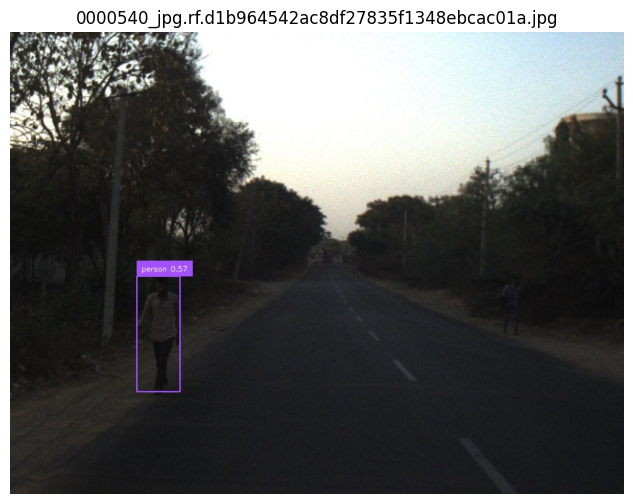

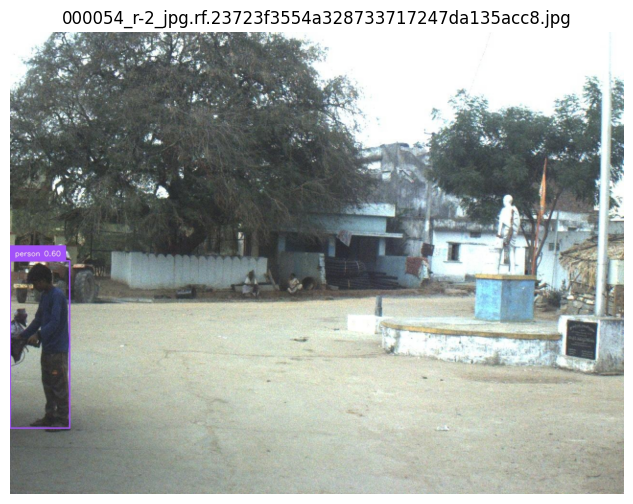

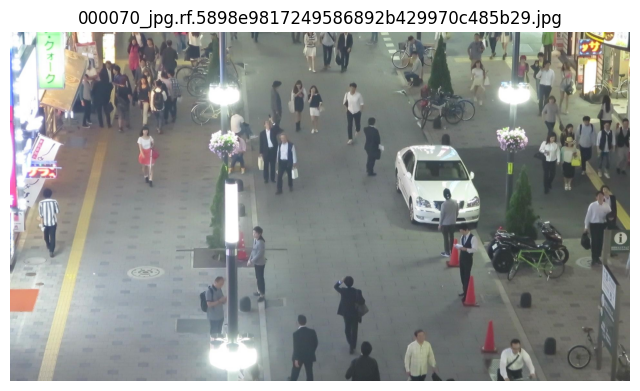

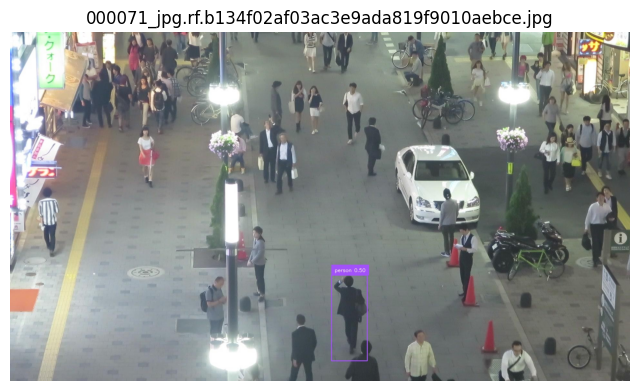

In [35]:
# import required libraries
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# locate all saved prediction images
prediction_folder = Path("predictions")
prediction_images = sorted(prediction_folder.glob("*.jpg"))

# display up to 4 prediction images
for image_path in prediction_images[:4]:

    # open the image
    image = Image.open(image_path)

    # display the image
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")
    plt.show()

In [36]:
# print the evaluation results obtained during validation

print("=" * 50)
print("RF-DETR MODEL EVALUATION")
print("=" * 50)

print(f"Accuracy (Classification): 53.10%") # classification accuracy (estimated from matched detections)
print(f"Precision: 0.5424 (54.24%)") # precision
print(f"Recall: 0.5203 (52.03%)") # recall
print(f"F1 Score: 0.5311 (53.11%)") # f1 score
print(f"mAP@0.5: 0.5101 (51.01%)") # mean average precision at IoU=0.5
print(f"mAP@0.5:0.95: 0.2859 (28.59%)") # mean average precision across IoU thresholds
print(f"Average Recall (AR): 0.4593 (45.93%)") # average recall

RF-DETR MODEL EVALUATION
Accuracy (Classification): 53.10%
Precision: 0.5424 (54.24%)
Recall: 0.5203 (52.03%)
F1 Score: 0.5311 (53.11%)
mAP@0.5: 0.5101 (51.01%)
mAP@0.5:0.95: 0.2859 (28.59%)
Average Recall (AR): 0.4593 (45.93%)


In [37]:
# function to calculate Intersection over Union (IoU)
def calculate_iou(boxA, boxB):

    # determine the coordinates of the intersection rectangle
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    intersection = max(0, xB - xA) * max(0, yB - yA) # compute the area of intersection

    # compute the area of each bounding box
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    union = areaA + areaB - intersection # compute the union area
    
    return intersection / union if union > 0 else 0 # return the IoU value


# example bounding boxes
ground_truth = [100, 100, 250, 300]
prediction = [120, 120, 240, 290]

iou = calculate_iou(ground_truth, prediction) # calculate IoU

print("IoU:", round(iou, 4)) # print the result

# determine if the prediction is considered a true positive
if iou >= 0.5:
    print("Result: True Positive (IoU ≥ 0.5)")
else:
    print("Result: False Positive (IoU < 0.5)")

IoU: 0.68
Result: True Positive (IoU ≥ 0.5)
